In [15]:
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patches as patches
from adjustText import adjust_text
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import seaborn as sns
import glob
from matplotlib.ticker import ScalarFormatter, LogFormatter, FuncFormatter
import sys

sys.path.insert(1, '../')
from Functions import *
import MetricMapping

# Access the mappings:
type_mapping = MetricMapping.type_mapping
name_mapping = MetricMapping.name_mapping

In [16]:
datadir = '/scratch/hydro4/users/kv25483/MetricEvaluation/Data/IntermediateFiles/'
figdir = '/scratch/hydro4/users/kv25483/MetricEvaluation/Figures/'

In [17]:
resolutions = ['dmc']

## Prepare the data
### Get the data

In [18]:
just_5m = pd.read_csv(datadir+"/Just5m.csv")

In [19]:
# transformed_minmax_scaled = pd.read_csv(datadir+"/NotScaled_RawVsDMC_new.csv")

# for res in resolutions:

#     del transformed_minmax_scaled[f'min_intensity{res}']
#     del transformed_minmax_scaled[f'frac_q1_wi{res}'] 
#     del transformed_minmax_scaled[f'frac_q2_wi{res}']  
#     del transformed_minmax_scaled[f'frac_q3_wi{res}']  
#     del transformed_minmax_scaled[f'frac_q4_wi{res}']  
#     del transformed_minmax_scaled[f'duration{res}']  
    
# column_names = transformed_minmax_scaled.columns.str.replace('_log', '')
# column_names = column_names.str.replace('_yj', '')
# transformed_minmax_scaled.columns = column_names

In [20]:
# this is missed out of metric calculations by accident
# transformed_minmax_scaled['cv_DMC_10'] = transformed_minmax_scaled['std_DMC_10']/transformed_minmax_scaled['mean_intensity_DMC_10']

### Get a list of metrics

In [21]:
metrics = list(name_mapping.keys())
categorical_metrics = ['3rd_ARR',  '3rd_rcg',  '3rd_w_peak', '4th_w_peak', '5th_w_peak', 'third_ppr', '3rd_w_most', 
                       '4th_w_most', '5th_w_most']
continuous_metrics = [metric for metric in list(type_mapping.keys()) if metric not in categorical_metrics]

# categorical_metrics = categorical_metrics = [col + '_raw' for col in categorical_metrics]
# continuous_metrics = continuous_metrics = [col + '_raw' for col in continuous_metrics]

### Calculate statistics on the data

In [22]:
summary_df = compute_metric_sensitivity_bynormalisation(df=just_5m,
    continuous_metrics=continuous_metrics,
    categorical_metrics=categorical_metrics,
    resolutions =resolutions)
summary_df["type2"] = summary_df["metric"].map(type_mapping)

dmc
missing column I30_raw or I30_dmc


/scratch/hydro4/users/kv25483/MetricEvaluation/Scripts/4. CompareNormalisation/New/../Functions.py:165: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rank_corr, _ = spearmanr(x, y)


In [23]:
# items = ['frac_q1_wi', 'frac_q2_wi', 'frac_q3_wi', 'frac_q4_wi', 'I30', 'centre_gravity_interpolated'] 
# ordered_types = list(type_mapping.keys())
# ordered_types.remove("lorenz_asymmetry")
# ordered_types = [i for i in ordered_types if i not in items]
# summary_df = summary_df.set_index('metric').loc[ordered_types].reset_index()

### Get versions of the data split by metric type`

In [24]:
df_continuous = summary_df[summary_df["type"] != "categorical"]
# Because mean intensirt has a rank correlaiton of NA
df_continuous = df_continuous[df_continuous['metric'] != 'mean_intensity'].copy()
unique_metrics_continuous = df_continuous['metric'].unique().tolist()

df_categorical = summary_df[summary_df["type"] == "categorical"]
unique_metrics_categorical = df_categorical['metric'].unique().tolist()

## Plotting
### Scatter plot

/tmp/ipykernel_3023095/3425483412.py:204: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


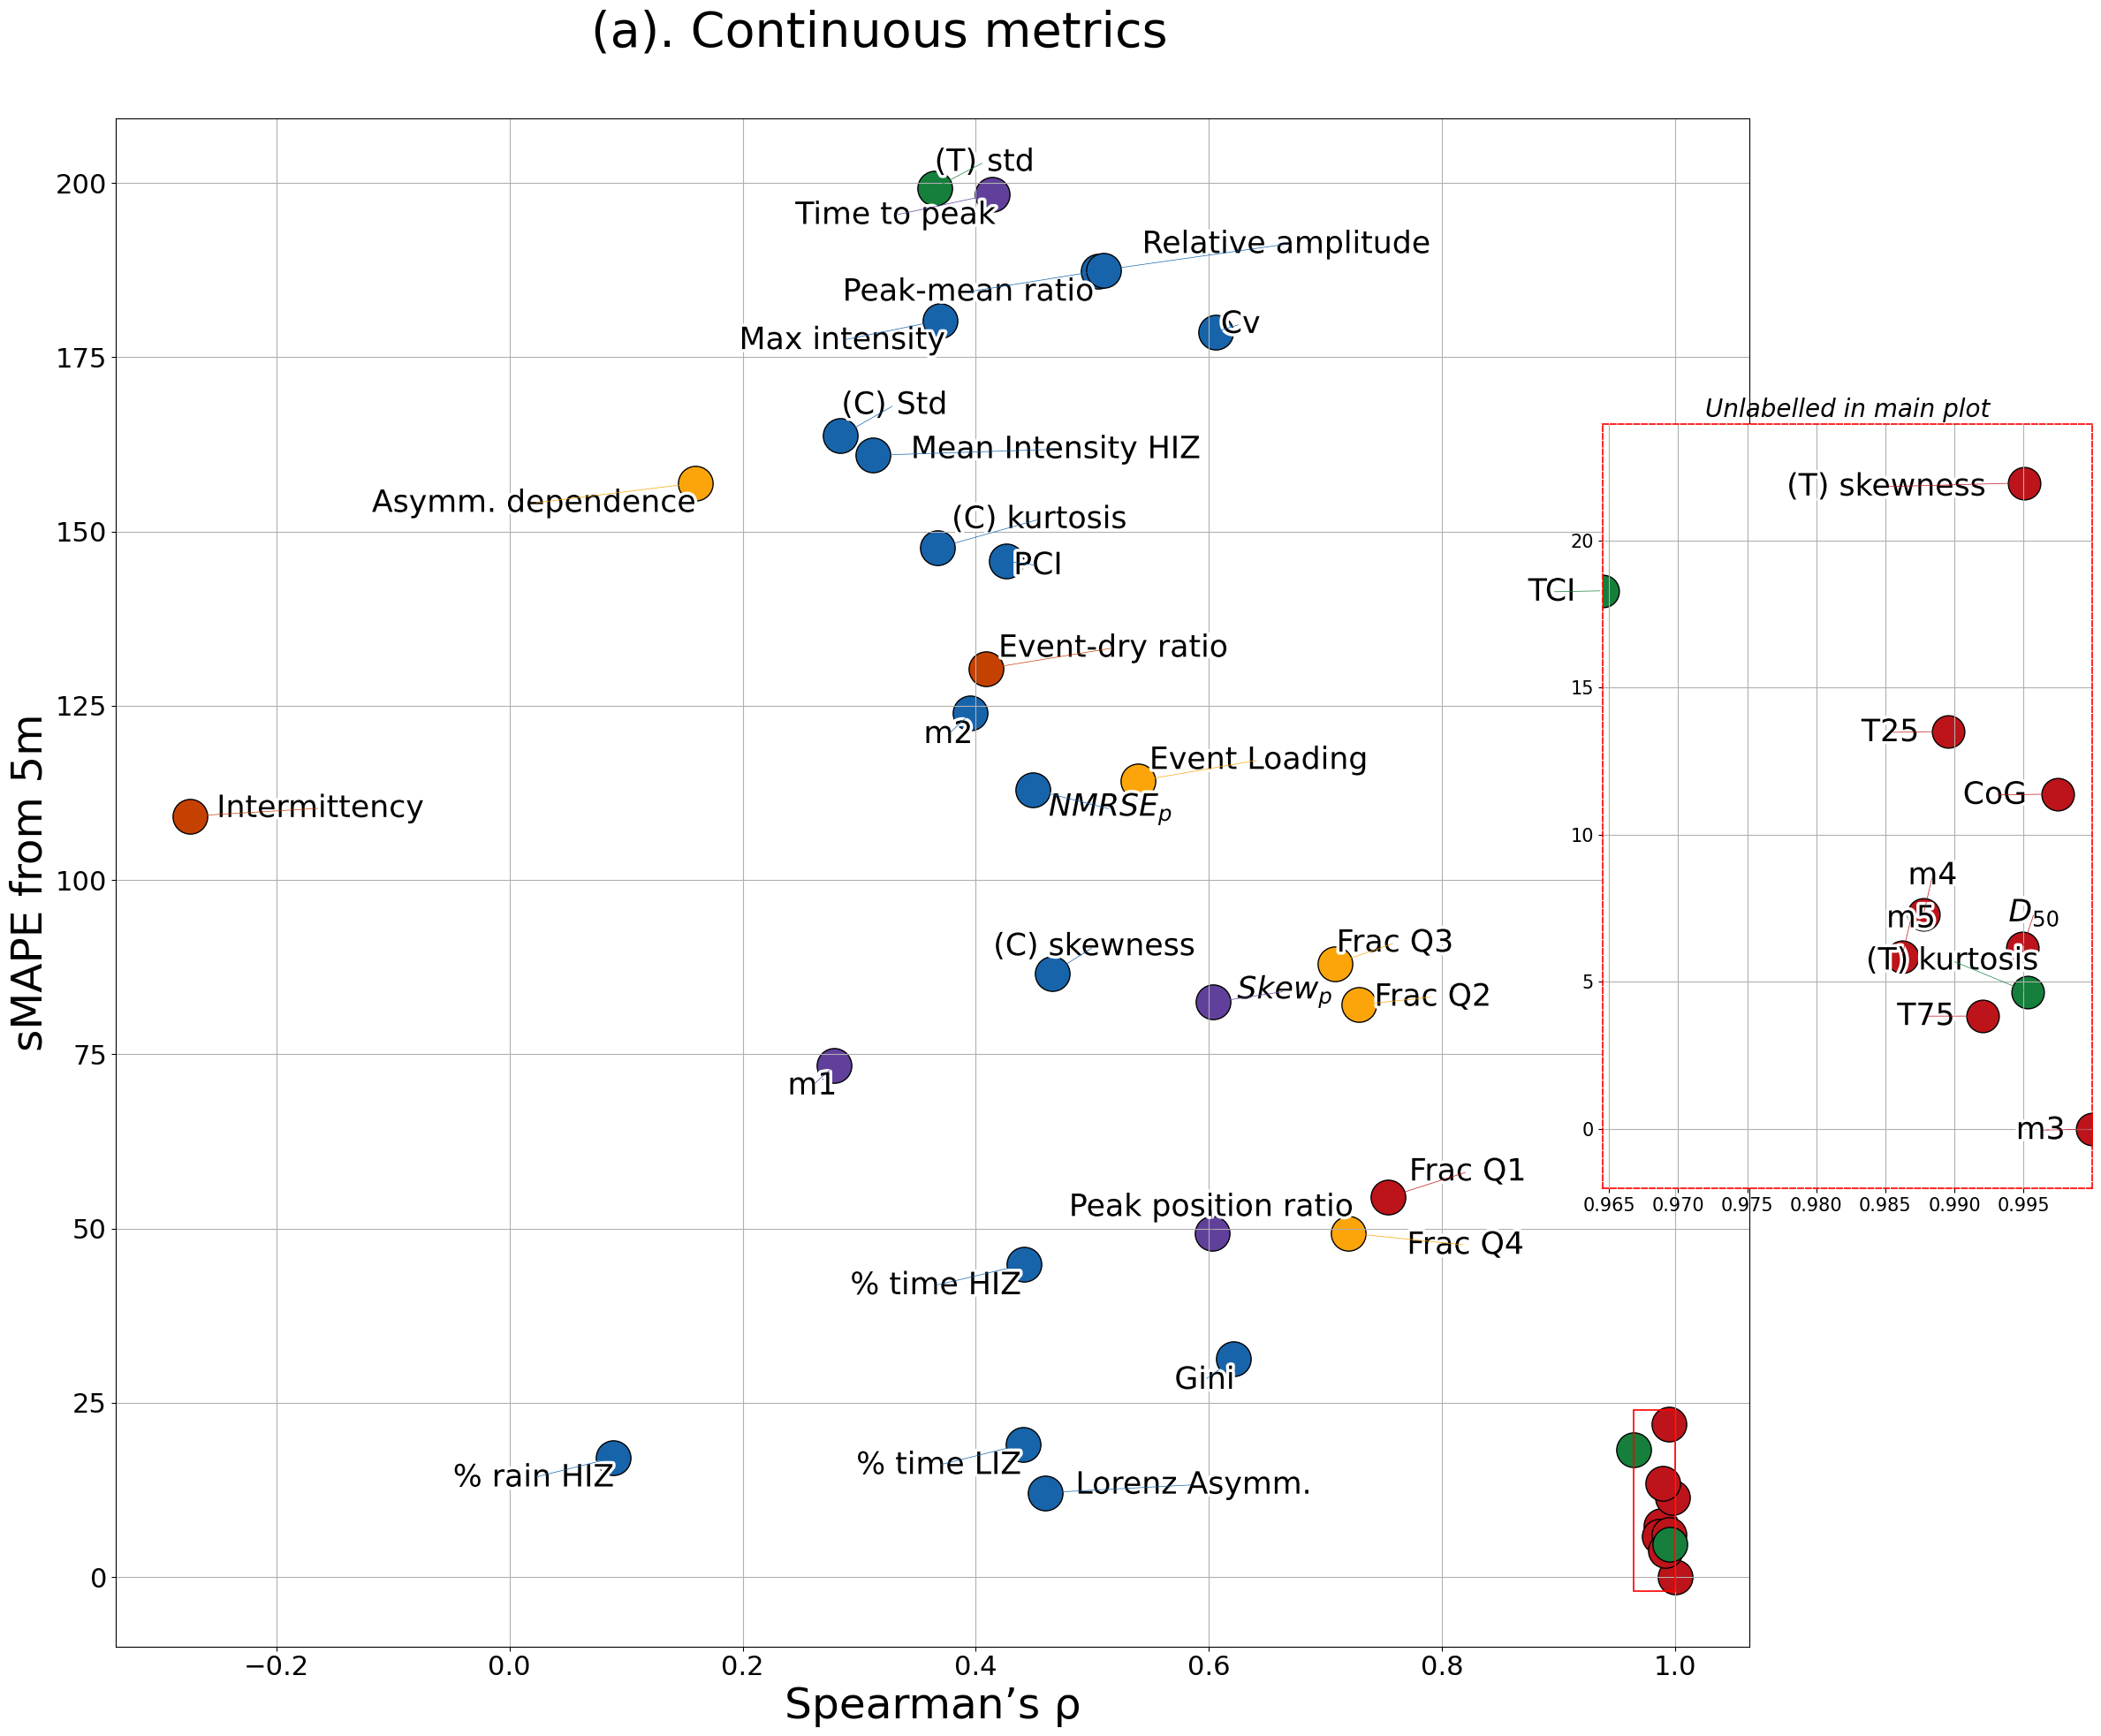

In [25]:
import matplotlib.patheffects as pe

size = 800
labelsize = 25
texts = []
marker = 'o'

# Determine which points to label
mask_label = ~((df_continuous["rank_corr"] > 0.96) & (df_continuous["val_diff"] < 25))
df_label = df_continuous[mask_label]
df_skip = df_continuous[~mask_label]

fig, ax = plt.subplots(figsize=(20, 20))

# --- Main plot: plot all points ---
original_positions = []
face_colors = []
texts = []

for _, row in df_continuous.iterrows():
    face_color = type_color_map_3[row['type2']][1]

    ax.scatter(row["rank_corr"],  row["val_diff"], facecolor=face_color, edgecolor="black",
        marker=marker, s=size,  alpha=1)

ax.tick_params(axis='both', which='major', labelsize=22)

# --- Add labels to selected points ---
for _, row in df_label.iterrows():

    face_color = type_color_map_3[row['type2']][1]

    # Start exactly at the point so there is no directional bias
    dx = 0
    dy = 0

    txt = ax.text(row["rank_corr"] + dx,
        row["val_diff"] + dy,  name_mapping[row["metric"]], fontsize=labelsize, color='black', ha="center", va="center" )

    txt.set_path_effects([pe.withStroke(linewidth=5, foreground="white")])

    texts.append(txt)

    original_positions.append((row["rank_corr"], row["val_diff"]))
    face_colors.append(face_color)

# --- Adjust labels (no arrows during optimisation) ---
adjust_text(
    texts,
    ax=ax,
    only_move={'text': 'xy'},
    ensure_inside_axes=True,
    arrowprops=None)

# --- Draw coloured leader lines afterwards ---
for txt, (x0, y0), face_color in zip(texts, original_positions, face_colors):

    x1, y1 = txt.get_position()

    ax.annotate(
        "",
        xy=(x0, y0),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="-",
            color=face_color,
            lw=0.5) )

# --- Inset plot for skipped labels ---
ax_inset = inset_axes(
    ax,
    width="30%",
    height="50%",
    loc='upper left',
    bbox_to_anchor=(0.91, -0.2, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0.0)

# Make inset border red
for spine in ax_inset.spines.values():
    spine.set_edgecolor('red')
    spine.set_linewidth(1.2)
    spine.set_linestyle('--')
    

texts_inset = []
positions_inset = []      # add this
face_colors_inset = []    # add this

for _, row in df_skip.iterrows():

    face_color = type_color_map_3[row['type2']][1]

    ax_inset.scatter(
        row["rank_corr"],
        row["val_diff"],
        facecolor=face_color,
        edgecolor='black',
        marker=marker,
        s=size-100,
        alpha=1)
    
    positions_inset.append((row["rank_corr"], row["val_diff"]))   # add this
    face_colors_inset.append(face_color)                          # add this

    dx = -0.001
    dy = 0.5
    
    txt = ax_inset.text(
        row["rank_corr"] + dx,
        row["val_diff"] + dy,
        name_mapping[row["metric"]],
        fontsize=labelsize,
        ha="right",     # key change
        va="center")

    txt.set_path_effects([
        pe.withStroke(linewidth=5, foreground="white")])

    texts_inset.append(txt)

adjust_text(
    texts_inset,
    ax=ax_inset,
    expand_text=(1.2, 1.4),
    expand_points=(2.2, 2.6),
    force_text=0.6,
    force_points=0.4,
    pull_threshold=10,
    lim=1000,
    only_move={'text': 'xy'},
    ensure_inside_axes=False,
    expand_axes=True,
    arrowprops=None)


for txt, (x0, y0), face_color in zip(texts_inset, positions_inset, face_colors_inset):

    x1, y1 = txt.get_position()

    ax_inset.annotate(
        "",
        xy=(x0, y0),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="-",
            color=face_color,
            lw=0.5,
#             connectionstyle="arc3,rad=0.15"
        ))

# --- Tidy inset ---
ax_inset.set_title("Unlabelled in main plot", fontsize=20, fontstyle="italic")
ax_inset.tick_params(axis='both', which='major', labelsize=15)
ax_inset.grid(True)

ax_inset.set_xlim(df_skip["rank_corr"].min(), df_skip["rank_corr"].max())
ax_inset.set_ylim(df_skip["val_diff"].min() - 2, df_skip["val_diff"].max() + 2)

# --- Main axes ---
ax.set_xlabel("Spearman’s ρ", fontsize=35)
ax.set_ylabel("sMAPE from 5m", fontsize=35)
ax.grid(True)

# --- Rectangle showing inset region ---
x0, x1 = ax_inset.get_xlim()
y0, y1 = ax_inset.get_ylim()

rect = patches.Rectangle(
    (x0, y0),
    x1 - x0,
    y1 - y0,
    linewidth=1.2,
    edgecolor='red',
    facecolor='none',
    linestyle='-',
    zorder=5)

ax.add_patch(rect)

# Connect inset to main plot
corners = [(x0, y0), (x0, y1), (x1, y1), (x1, y0)]
inset_corners = [
    (ax_inset.get_xlim()[0], ax_inset.get_ylim()[0]),
    (ax_inset.get_xlim()[0], ax_inset.get_ylim()[1]),
    (ax_inset.get_xlim()[1], ax_inset.get_ylim()[1]),
    (ax_inset.get_xlim()[1], ax_inset.get_ylim()[0])]

for (x_main, y_main), (x_in, y_in) in zip(corners, inset_corners):

    line = Line2D(
        [x_main, x_in],
        [y_main, y_in],
        transform=ax.transData,
        color='red',
        linestyle='--',
        linewidth=2)

    fig.add_artist(line)

# --- Title ---
fig.suptitle( "(a). Continuous metrics", fontsize=40)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

fig.savefig(figdir + "CompareNormalisation/Scatter_continuous_DMC10.png",
    dpi=300, facecolor='white', bbox_inches='tight')

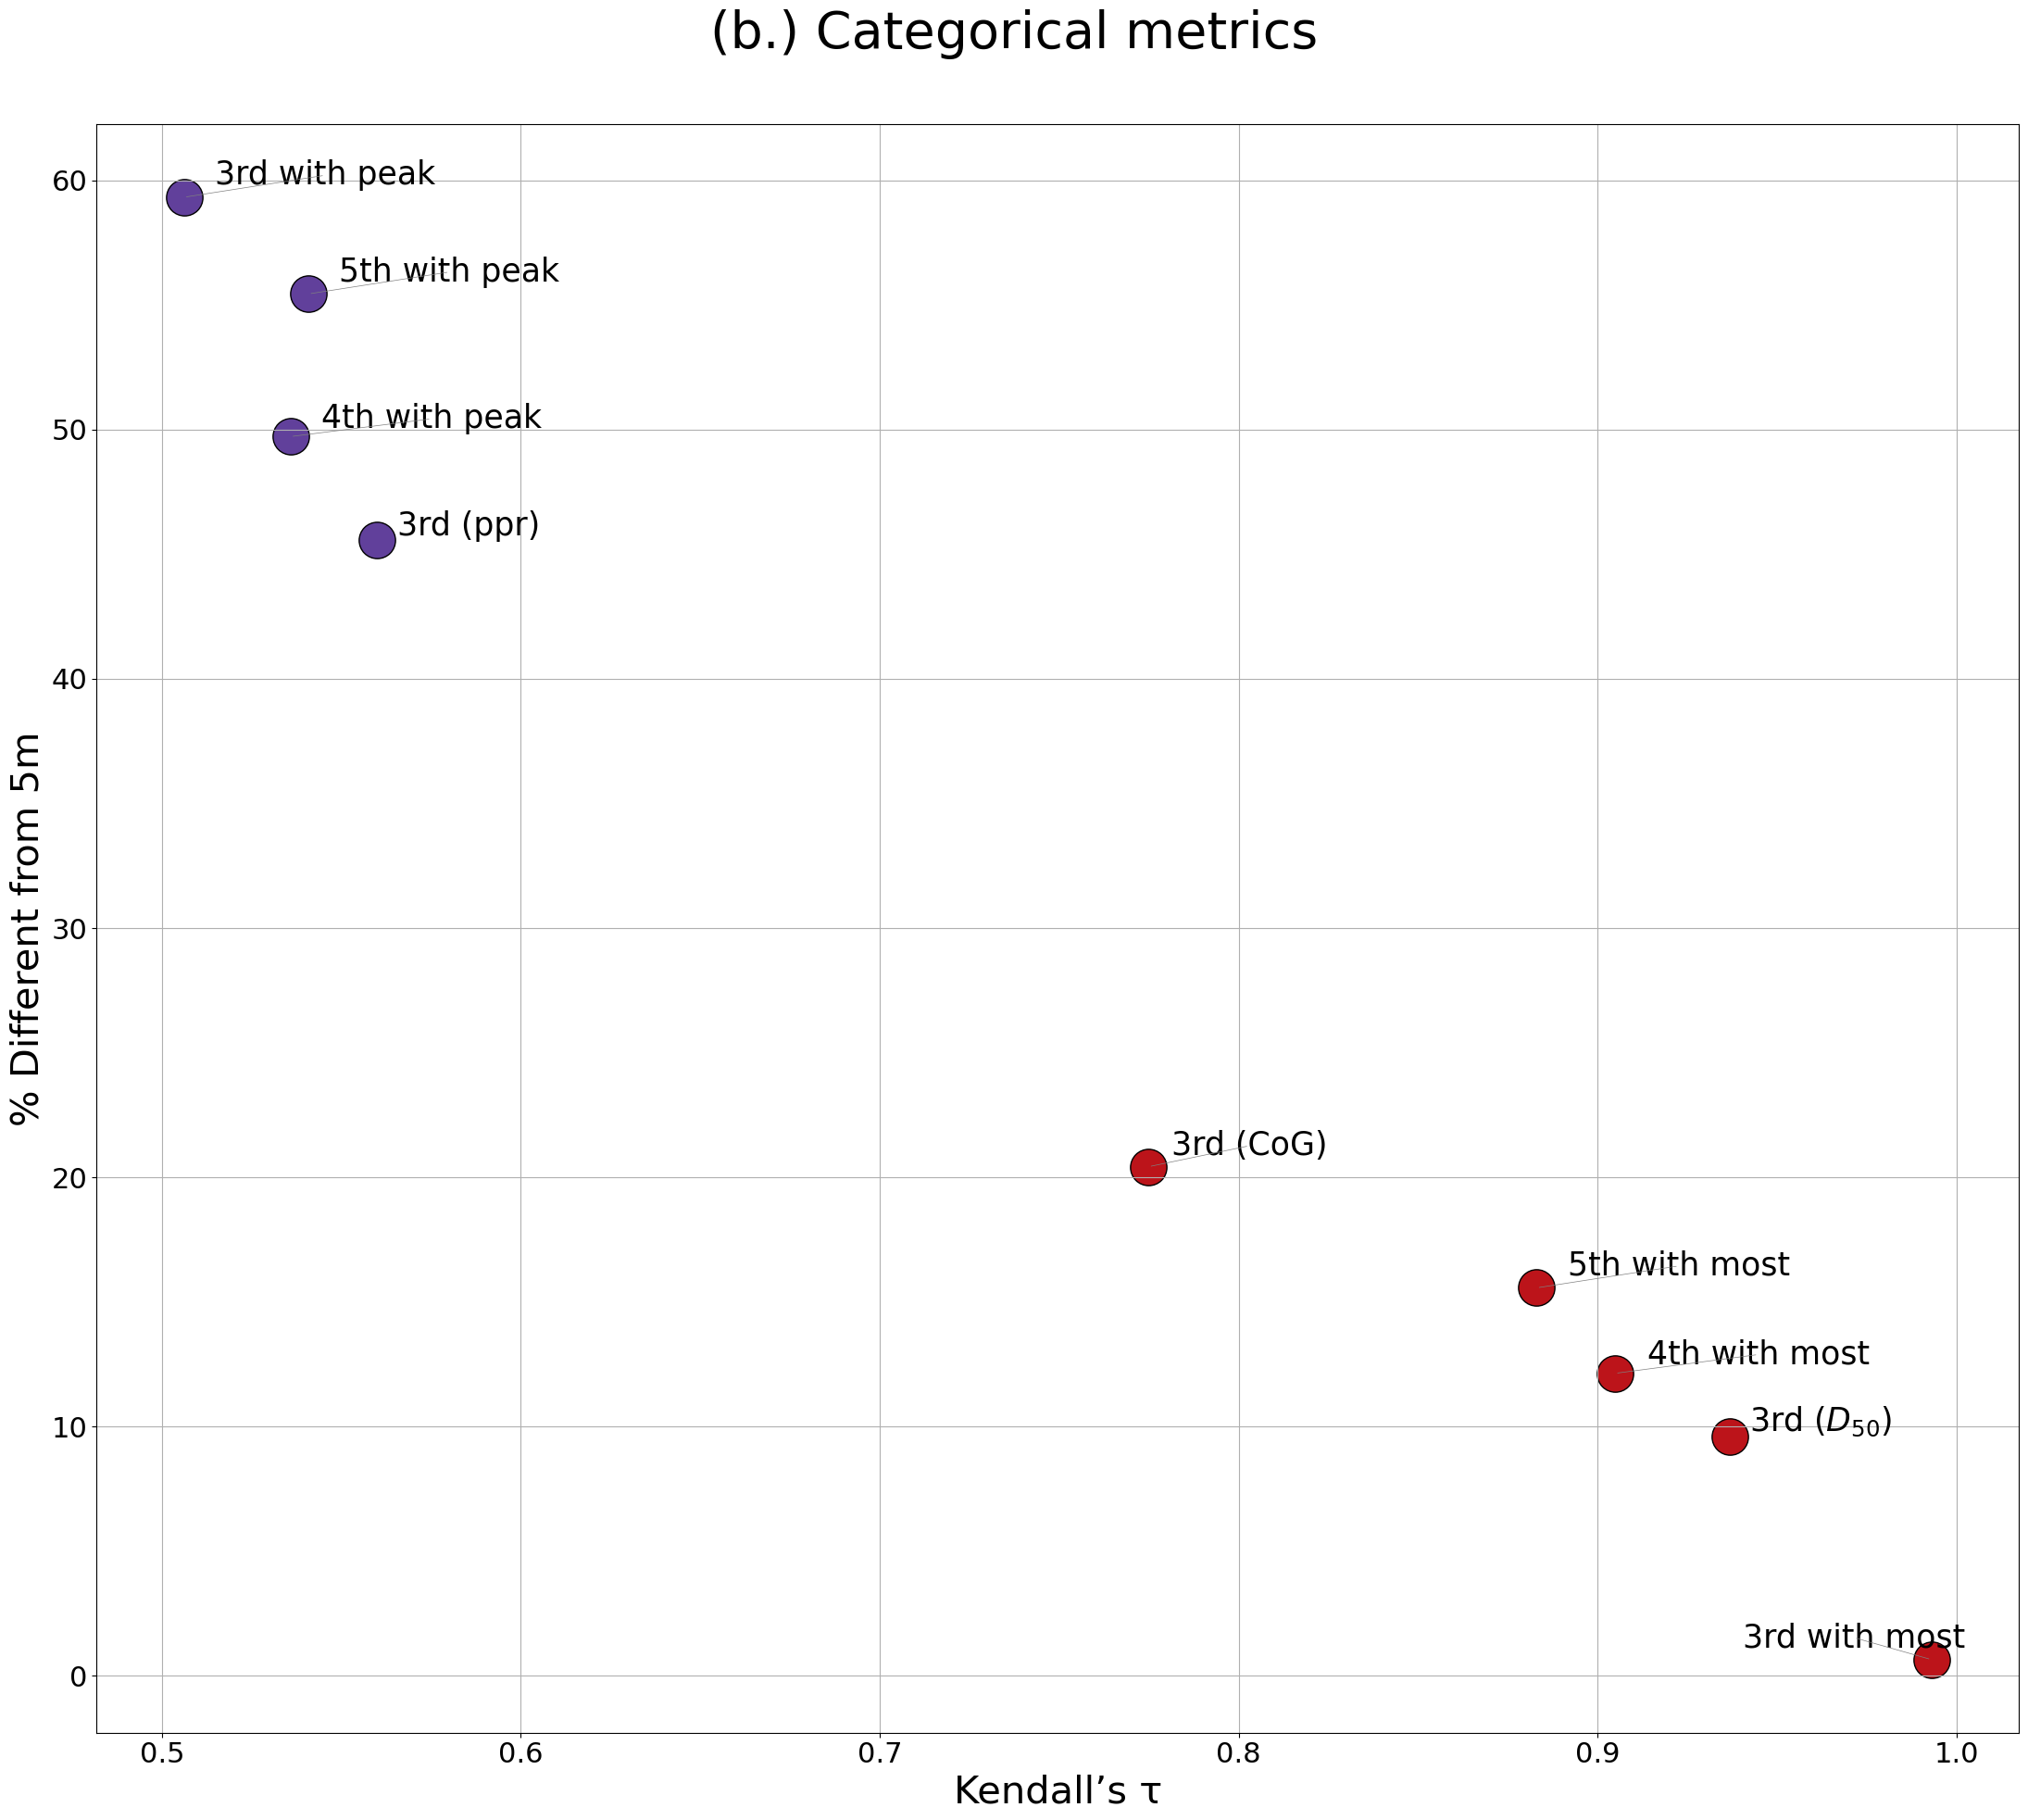

In [26]:
fig, ax = plt.subplots(figsize=(22, 20))  # Expanded canvas

marker = 'o'
size = 800
labelsize = 25
texts = []

for _, row in df_categorical.iterrows():
    # Scatter point
    ax.scatter(
        row["rank_corr"],
        row["val_diff"],
        facecolor=type_color_map_3[row['type2']][1],
        edgecolor='black',
        marker=marker,
        s=size,
        alpha=1)
    # Clean label name
    metric_name = name_mapping[row["metric"]]
    
    # Create text object (to be adjusted later)
    texts.append(
        ax.text(row["rank_corr"], row["val_diff"], metric_name, fontsize=labelsize))
ax.tick_params(axis='both', which='major', labelsize=22)
# Axes labels
ax.set_xlabel("Kendall’s τ", fontsize=30)
ax.set_ylabel("% Different from 5m", fontsize=30)
ax.grid(True)
# Adjust text to avoid overlaps
adjust_text(texts,
     ax=ax,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
    expand_text=(1.05, 1.2),
    expand_points=(1.2, 1.4),
    only_move={'points': 'xy', 'text': 'xy'},
    force_points=0.5,
    force_text=1.2)

fig.suptitle("(b.) Categorical metrics", fontsize=40)
plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(figdir+ "CompareNormalisation/Scatter_categorical_DMC10.png", dpi=300, facecolor='white', bbox_inches='tight')

## Legend

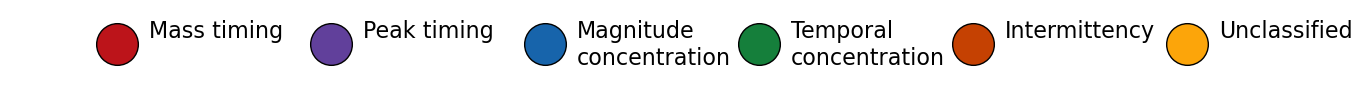

In [27]:
legend_types = list(type_color_map_3.keys())

# Create figure
fig, ax = plt.subplots(figsize=(14, 1))

# Plot circles and labels
for i, label in enumerate(legend_types):
    
    color = type_color_map_3[label][1]
    
    # Handle long titles
    title = label.replace(" ", "\n", 1) if len(label) > 20 else label
    if "\n" not in title:
        title = title + "\n "  # blank second line for spacing
    
    ax.scatter(i, 0, s=900, color=color, edgecolor='black')
    ax.text(i + 0.15, 0, title, va='center', fontsize=16)

# Remove axes
ax.set_xlim(-0.5, len(legend_types)-0.2)
ax.set_ylim(-0.5, 0.5)
ax.axis("off")

plt.tight_layout()

# Save if needed
plt.savefig(figdir + "CompareNormalisation/Scatter_DMC10_legend.png", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()

### Combine figures into one

In [28]:
from PIL import Image, ImageDraw, ImageFont
import math

def combine_images_grid(image_paths, out_path,
                        ncols=6, pad=10, bg_color=(255,255,255),
                        dpi=300, labels=None):
    imgs = [Image.open(p).convert("RGB") for p in image_paths]
    widths, heights = zip(*(i.size for i in imgs))
    cell_w = max(widths)
    cell_h = max(heights)

    n = len(imgs)
    nrows = -(-n // ncols)   # ceiling division
    out_w = ncols*cell_w + pad*(ncols+1)
    out_h = nrows*cell_h + pad*(nrows+1)
    canvas = Image.new("RGB", (out_w, out_h), bg_color)

    for idx, img in enumerate(imgs):
        r = idx // ncols
        c = idx % ncols
        x = pad + c*(cell_w + pad)
        y = pad + r*(cell_h + pad)
        # center image in cell
        img_w, img_h = img.size
        paste_x = x + (cell_w - img_w)//2
        paste_y = y + (cell_h - img_h)//2
        canvas.paste(img, (paste_x, paste_y))

        # optional label under the image
        if labels:
            draw = ImageDraw.Draw(canvas)
            try:
                font = ImageFont.truetype("DejaVuSans.ttf", 12)
            except Exception:
                font = ImageFont.load_default()
            text = labels[idx]
            tw, th = draw.textsize(text, font=font)
            draw.rectangle([paste_x, paste_y+img_h - th - 6, paste_x + tw + 6, paste_y+img_h],
                           fill=(255,255,255))
            draw.text((paste_x+3, paste_y+img_h - th - 4), text, fill=(0,0,0), font=font)

    # save (PNG or PDF). dpi metadata set to (dpi,dpi)
    canvas.save(out_path, dpi=(dpi, dpi))
    
# Collect all PNGs (adjust pattern/order as needed)
files = sorted(glob.glob(figdir + "CompareNormalisation/Scatter_continuous_DMC10.png")) + \
        sorted(glob.glob(figdir + "CompareNormalisation/Scatter_categorical_DMC10.png")) 

combine_images_grid(files, figdir+"CompareNormalisation/Scatter_combined_DMC_10.png", ncols=2, pad=12, dpi=300)

OSError: image file is truncated